# NOTEBOOK 01: *ANÁLISIS*

# LIBRERÍAS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# Evitamos notación científica

pd.options.display.float_format = '{:.2f}'.format

In [20]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

In [21]:
print("Working with these versions of libraries\n")
print("-"*50)
print(f"pandas  version {pd.__version__}")
print(f"numpy   version {np.__version__}")
print(f"seaborn version {sns.__version__}")

Working with these versions of libraries

--------------------------------------------------
pandas  version 2.2.3
numpy   version 2.2.2
seaborn version 0.13.2


In [22]:
df_sales = pd.read_csv("data/item_sales.csv")
df_calendar = pd.read_csv("data/daily_calendar_with_events.csv")
df_prices = pd.read_csv("data/item_prices.csv")

# FUNCIONES

In [23]:
def explorar_df(dataframe):
    print(f""" Primeras 5 filas:
    {dataframe.head()}

    Últimas 5 filas:
    {dataframe.tail()}

    Tipo de datos:""")
    dataframe.info()

    print(f"""

    Cantidad de nulos:
    {dataframe.isnull().sum()}

    Distribución de valores:
    {dataframe.describe(include='all')}

    Análisis de categóricas:
    """)

    for col in dataframe.select_dtypes(include=['object', 'category']):
        print(f"--- {col} ---")
        print(dataframe[col].value_counts(), "\n")


In [24]:
def fix_yearweek(series):
    max_weeks = 53  
    prev_year, prev_week = divmod(series.iloc[0], 100) 
    new_values = []
    
    for yw in series:
        if pd.isna(yw):
            prev_week += 1
            if prev_week > max_weeks: 
                prev_week = 1
                prev_year += 1
            yw = prev_year * 100 + prev_week
        else:
            prev_year, prev_week = divmod(yw, 100)
        new_values.append(yw)
    
    return new_values

In [25]:
def pick_priority_event(events_series):
    # Eliminamos nulos
    events_series = events_series.dropna()
    # Filtramos los que sean distintos de "No event"
    non_no_event = events_series[events_series != "No event"]
    
    if not non_no_event.empty:
        # Devuelve el primer evento distinto de "No event"
        return non_no_event.iloc[0]
    else:
        # Si no hay ninguno distinto, devuelve "No event"
        return "No event"

In [26]:
def pareto_por_tiendas(df):
    # Calculamos el número total de productos únicos en la ciudad
    total_productos = df["item"].nunique()

    # Obtenemos lista de tiendas en esta ciudad
    tiendas_en_ciudad = df["store"].unique()

    # Recorrermos cada tienda de la ciudad seleccionada
    for tienda in tiendas_en_ciudad:

        # Filtrar¡mos datos de la tienda específica
        df_final_tienda = df[df["store"] == tienda]

        # Calculamos número de productos vendidos en esta tienda
        productos_vendidos = df_final_tienda[df_final_tienda["units_sold"] > 0]["item"].nunique()

        # Calculamos los productos que generan el 80% de ventas en esta tienda
        ventas_por_producto = df_final_tienda.groupby("item")["units_sold"].sum().reset_index()
        ventas_por_producto = ventas_por_producto.sort_values(by="units_sold", ascending=False)

        ventas_por_producto["ventas_acumuladas"] = ventas_por_producto["units_sold"].cumsum()
        ventas_por_producto["porcentaje_acumulado"] = ventas_por_producto["ventas_acumuladas"] / ventas_por_producto["units_sold"].sum()

        productos_pareto = ventas_por_producto[ventas_por_producto["porcentaje_acumulado"] <= 0.8].shape[0]

        # Creamos DataFrame para gráficos
        comparacion_tienda = pd.DataFrame({
            "Categoría": ["Total de Productos", "Productos con Ventas", "Productos que generan el 80% de ventas"],
            "Cantidad": [total_productos, productos_vendidos, productos_pareto]
        })

        # Gráfico de Barras para esta tienda
        plt.figure(figsize=(6,5))
        sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")

        plt.xlabel("Categoría")
        plt.ylabel("Cantidad de Productos")
        plt.title(f"Análisis de Productos en {tienda} (Nueva York)")
        plt.xticks(rotation=30)
        plt.ylim(0, total_productos + 100)  # Ajustamos el límite del gráfico para mejor visualización

        plt.show()

        # Mostramos resultados numéricos
        print(f"**Análisis de la tienda {tienda} en Nueva York:**")
        print(f"- Total de productos disponibles: {total_productos}")
        print(f"- Productos con al menos una venta: {productos_vendidos} ({(productos_vendidos/total_productos)*100:.2f}%)")
        print(f"- Productos que generan el 80% de las ventas: {productos_pareto}")
        print("-" * 50)

In [27]:
def univariate_analysis(df, column, cat_threshold=20, top_n=20):
    """
    Realiza un análisis univariado para una sola columna de un DataFrame.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame que contiene la columna a analizar.
    column : str
        Nombre de la columna a analizar.
    cat_threshold : int
        Umbral de cardinalidad para decidir si se hace un gráfico completo o solo top_n categorías.
    top_n : int
        Número de categorías más frecuentes a mostrar si la cardinalidad excede cat_threshold.
    """
    
    # Verificamos si la columna existe en el DataFrame
    if column not in df.columns:
        print(f"La columna '{column}' no existe en el DataFrame.")
        return
    
    # Obtenemos los datos de la columna
    col_data = df[column]
    
    # Verificamos el tipo de dato de la columna
    if pd.api.types.is_numeric_dtype(col_data):
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Histograma
        sns.histplot(data=df, x=column, y=target, kde=True, ax=axes[0])
        axes[0].set_title(f"Histograma de '{column}'")
        
        # Boxplot
        sns.boxplot(data=df, x=column, y=target, ax=axes[1])
        axes[1].set_title(f"Boxplot de '{column}'")
        
        plt.tight_layout()
        plt.show()
        
        # Resumen estadístico
        print(f"Resumen estadístico de la columna '{column}':")
        display(col_data.describe())
        
        # Conteo de valores nulos
        missing_count = col_data.isnull().sum()
        print(f"\nValores nulos en '{column}': {missing_count}")
        
    else:
        # Es una columna categórica (object, category, etc.)
        
        # Conteo de categorías únicas
        unique_vals = col_data.nunique()
        print(f"La columna '{column}' tiene {unique_vals} categorías únicas.")
        
        # Resumen de frecuencia
        freq_table = col_data.value_counts(dropna=False)
        
        # Mostramos la tabla de frecuencia completa si es pequeña,
        # o las top_n categorías si la cardinalidad es grande
        if unique_vals <= cat_threshold:
            print("\nTabla de frecuencia completa:")
            display(freq_table)
            
            # Gráfico de barras con todas las categorías
            plt.figure(figsize=(8, 4))
            sns.countplot(data=df, x=column, order=freq_table.index)
            plt.title(f"Distribución de '{column}'")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"La cardinalidad excede el umbral de {cat_threshold}. Mostrando las {top_n} categorías más frecuentes:\n")
            display(freq_table.head(top_n))
            
            # Gráfico de barras con las top_n categorías
            top_cats = freq_table.head(top_n)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=top_cats.values, y=top_cats.index)
            plt.title(f"Top {top_n} categorías de '{column}'")
            plt.tight_layout()
            plt.show()
        
        # Conteo de valores nulos
        missing_count = col_data.isnull().sum()
        print(f"\nValores nulos en '{column}': {missing_count}")

In [28]:
def rellenar_ceros_hasta_primer_valor(df, group_cols, target_col):
    def fill_zeros(x):
        x = x.copy()  # Copia la serie para evitar modificaciones en el original
        mask = x.notnull()  # Encuentra los valores no nulos
        if mask.any():  # Si hay al menos un valor no nulo
            first_valid_index = mask.idxmax()  # Encuentra la primera posición con un valor no nulo
            x.loc[:first_valid_index-1] = 0  # Rellena con 0 hasta esa posición
        return x
    
    return df.groupby(group_cols, group_keys=False)[target_col].apply(fill_zeros)

In [29]:
def nulos_sell_price(df):
    # Calculamos la media de 'sell_price' por grupo (item, region, store, year, quarter)
    group_mean = df.groupby(["item","region", "year"])["sell_price"].transform("mean")
    
    # Rellenamos los valores nulos con la media del grupo
    df["sell_price"] = df["sell_price"].fillna(group_mean)
    
    # Si aún quedan nulos, rellenamos con la media global del producto (item) en todo el dataset
    item_mean = df.groupby("item")["sell_price"].transform("mean")
    df["sell_price"] = df["sell_price"].fillna(item_mean)

    return df

In [30]:
# Función para calcular la pendiente de la regresión lineal de las ventas de un producto

def calcular_pendiente(item_sales):
    # Asegurarnos de que no hay valores nulos
    item_sales = item_sales.dropna()
    
    if len(item_sales) < 2:  # Asegurarse de que hay suficientes datos para realizar la regresión
        return np.nan
    
    # Definir las variables X (años) y Y (ventas)
    X = item_sales.index.values.reshape(-1, 1)  # Años como variable independiente
    y = item_sales.values  # Ventas como variable dependiente
    
    # Realizar la regresión lineal
    reg = LinearRegression().fit(X, y)
    
    # La pendiente es el coeficiente de la regresión lineal
    return reg.coef_[0]



In [31]:
def calcular_pareto(df):
    # Ordenamos los productos por cantidad de ventas
    df = df.sort_values(by="units_sold", ascending=False)

    # Calculamos las ventas acumuladas y el porcentaje acumulado
    df["ventas_acumuladas"] = df["units_sold"].cumsum()
    df["porcentaje_acumulado"] = df["ventas_acumuladas"] / df["units_sold"].sum()

    # Contamos los productos que generan el 80% de las ventas
    productos_pareto = df[df["porcentaje_acumulado"] <= 0.8].shape[0]

    return productos_pareto


# Exploración de Datos

### Dataframe_Prices

In [32]:
df_prices

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,201328.00,12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,201329.00,12.74
2,ACCESORIES_1_001,ACCESORIES,NYC_1,201330.00,10.99
3,ACCESORIES_1_001,ACCESORIES,NYC_1,201331.00,10.99
4,ACCESORIES_1_001,ACCESORIES,NYC_1,201332.00,10.99
...,...,...,...,...,...
6965701,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965702,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965703,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965704,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20


In [33]:
explorar_df(df_prices)

 Primeras 5 filas:
                   item    category store_code  yearweek  sell_price
0  ACCESORIES_1_001  ACCESORIES      NYC_1 201328.00       12.74
1  ACCESORIES_1_001  ACCESORIES      NYC_1 201329.00       12.74
2  ACCESORIES_1_001  ACCESORIES      NYC_1 201330.00       10.99
3  ACCESORIES_1_001  ACCESORIES      NYC_1 201331.00       10.99
4  ACCESORIES_1_001  ACCESORIES      NYC_1 201332.00       10.99

    Últimas 5 filas:
                          item     category store_code  yearweek  sell_price
6965701  SUPERMARKET_3_827  SUPERMARKET      PHI_3       NaN        1.20
6965702  SUPERMARKET_3_827  SUPERMARKET      PHI_3       NaN        1.20
6965703  SUPERMARKET_3_827  SUPERMARKET      PHI_3       NaN        1.20
6965704  SUPERMARKET_3_827  SUPERMARKET      PHI_3       NaN        1.20
6965705  SUPERMARKET_3_827  SUPERMARKET      PHI_3       NaN        1.20

    Tipo de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965706 entries, 0 to 6965705
Data columns (total 5 c

In [34]:
# Ordenamos los datos por 'item' y 'yearweek'
df_prices =df_prices.sort_values(["item", "yearweek"], ascending=[True, True])

# Rellenamos valores nulos de precios
df_prices["yearweek"] =df_prices.groupby("item")["yearweek"].ffill().bfill()

# Rellenamos nulos de semanas
df_prices["yearweek"] =df_prices.groupby("item")["yearweek"].transform(fix_yearweek)

In [35]:
df_prices.isnull().sum()

item          0
category      0
store_code    0
yearweek      0
sell_price    0
dtype: int64

In [36]:
df_prices['yearweek'] = df_prices['yearweek'].astype(int).astype(str).str.zfill(2)

In [37]:
df_prices['yearweek'].value_counts()

yearweek
201617    274410
201616     30490
201615     30490
201614     30490
201613     30490
201612     30490
201611     30490
201610     30490
201609     30490
201608     30490
201607     30490
201606     30482
201605     30482
201604     30479
201603     30477
201602     30475
201601     30474
201600     30474
201552     30474
201551     30466
201550     30466
201549     30466
201548     30463
201547     30462
201546     30462
201545     30461
201544     30452
201543     30450
201542     30439
201541     30433
201540     30430
201539     30421
201538     30407
201537     30403
201536     30398
201535     30392
201534     30381
201533     30373
201532     30371
201531     30370
201530     30360
201529     30353
201528     30348
201527     30341
201526     30334
201525     30333
201524     30331
201523     30324
201522     30306
201521     30238
201520     30106
201519     30102
201518     30084
201517     30075
201516     30063
201515     30056
201514     30048
201513     29995
20151

### Dataframe_Calendar

In [38]:
df_calendar

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN
...,...,...,...,...,...
1908,2016-04-20,Wednesday,5,d_1909,NaN
1909,2016-04-21,Thursday,6,d_1910,NaN
1910,2016-04-22,Friday,7,d_1911,NaN
1911,2016-04-23,Saturday,1,d_1912,NaN


In [39]:
explorar_df(df_calendar)

 Primeras 5 filas:
             date    weekday  weekday_int    d event
0  2011-01-29   Saturday            1  d_1   NaN
1  2011-01-30     Sunday            2  d_2   NaN
2  2011-01-31     Monday            3  d_3   NaN
3  2011-02-01    Tuesday            4  d_4   NaN
4  2011-02-02  Wednesday            5  d_5   NaN

    Últimas 5 filas:
                date    weekday  weekday_int       d event
1908  2016-04-20  Wednesday            5  d_1909   NaN
1909  2016-04-21   Thursday            6  d_1910   NaN
1910  2016-04-22     Friday            7  d_1911   NaN
1911  2016-04-23   Saturday            1  d_1912   NaN
1912  2016-04-24     Sunday            2  d_1913   NaN

    Tipo de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1913 non-null   object
 1   weekday      1913 non-null   object
 2   weekday_int  1913 non-null   int

In [40]:
# Cambiamos el formato de df_calendar['date'] a datetime

df_calendar['date'] = pd.to_datetime(df_calendar['date'])

In [41]:
df_calendar_new = df_calendar.copy()

In [42]:
df_calendar_new['year'] = df_calendar['date'].dt.year                       # Extraemos año
df_calendar_new['day'] = df_calendar['date'].dt.day                         # Extraemos día del mes
df_calendar_new['weekday'] = df_calendar['date'].dt.weekday                 # Extraemos día de la semana (0 = Lunes, 6 = Domingo)
df_calendar_new['quarter'] = df_calendar['date'].dt.quarter                  
df_calendar_new['day_of_year'] = df_calendar['date'].dt.day_of_year
df_calendar_new['week_number'] = df_calendar['date'].dt.isocalendar().week

In [43]:
del df_calendar_new['weekday_int']

In [44]:
df_calendar_new

,date,weekday,d,event,year,day,quarter,day_of_year,week_number
0,2011-01-29,5,d_1,NaN,2011,29,1,29,4
1,2011-01-30,6,d_2,NaN,2011,30,1,30,4
2,2011-01-31,0,d_3,NaN,2011,31,1,31,5
3,2011-02-01,1,d_4,NaN,2011,1,1,32,5
4,2011-02-02,2,d_5,NaN,2011,2,1,33,5
...,...,...,...,...,...,...,...,...,...
1908,2016-04-20,2,d_1909,NaN,2016,20,2,111,16
1909,2016-04-21,3,d_1910,NaN,2016,21,2,112,16
1910,2016-04-22,4,d_1911,NaN,2016,22,2,113,16
1911,2016-04-23,5,d_1912,NaN,2016,23,2,114,16


In [45]:
df_calendar_new['yearweek'] = df_calendar_new['year'].astype(str) + df_calendar_new['week_number'].astype(str).str.zfill(2)

In [46]:
df_calendar_new

,date,weekday,d,event,year,day,quarter,day_of_year,week_number,yearweek
0,2011-01-29,5,d_1,NaN,2011,29,1,29,4,201104
1,2011-01-30,6,d_2,NaN,2011,30,1,30,4,201104
2,2011-01-31,0,d_3,NaN,2011,31,1,31,5,201105
3,2011-02-01,1,d_4,NaN,2011,1,1,32,5,201105
4,2011-02-02,2,d_5,NaN,2011,2,1,33,5,201105
...,...,...,...,...,...,...,...,...,...,...
1908,2016-04-20,2,d_1909,NaN,2016,20,2,111,16,201616
1909,2016-04-21,3,d_1910,NaN,2016,21,2,112,16,201616
1910,2016-04-22,4,d_1911,NaN,2016,22,2,113,16,201616
1911,2016-04-23,5,d_1912,NaN,2016,23,2,114,16,201616


In [47]:
df_calendar_new.yearweek.nunique()

275

- Filtramos el df de forma semanal, ya que nuestro modelo va a predecir ventas por semana
- Eliminamos columnas que no nos hacen falta o son redundantes
- Imputamos nulos en la columna 'event'

In [48]:
df_calendar_new = df_calendar_new.sort_values("date")

df_calendar_weekly = (
    df_calendar_new
    .groupby("yearweek", as_index=False)
    .agg({
        "year": "first",
        "quarter": "first",
        "event": pick_priority_event
    })
)

df_calendar_weekly.head()

,yearweek,year,quarter,event
0,201104,2011,1,No event
1,201105,2011,1,SuperBowl
2,201106,2011,1,No event
3,201107,2011,1,No event
4,201108,2011,1,No event


In [49]:
df_calendar_weekly.event.value_counts()

event
No event          249
SuperBowl           6
Ramadan starts      5
Thanksgiving        5
Easter              5
NewYear             5
Name: count, dtype: int64

### Dataframe_Sales

In [50]:
df_sales

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,2,2,0,0,0,1,1,0,2,0,1,1,2,0,1,0,0,0,2,1,0,1,1,2,0,0,0,0,0,0,0,1,0,1,0,1,0,3,1,1,0,1,1,2,0,0,0,0,1,1,0,0,0,0,3,0,1,0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,2,0,0,0,0,1,1,2,0,0,0,0,2,0,0,1,1,1,1,0,0,0,0,0,1,2,2,0,1,0,0,0,0,1,2,1,0,0,0,0,0,1,0,3,0,1,2,1,0,3,

In [51]:
explorar_df(df_sales)

 Primeras 5 filas:
                           id              item    category    department  \
0  ACCESORIES_1_001_NYC_1  ACCESORIES_1_001  ACCESORIES  ACCESORIES_1   
1  ACCESORIES_1_002_NYC_1  ACCESORIES_1_002  ACCESORIES  ACCESORIES_1   
2  ACCESORIES_1_003_NYC_1  ACCESORIES_1_003  ACCESORIES  ACCESORIES_1   
3  ACCESORIES_1_004_NYC_1  ACCESORIES_1_004  ACCESORIES  ACCESORIES_1   
4  ACCESORIES_1_005_NYC_1  ACCESORIES_1_005  ACCESORIES  ACCESORIES_1   

               store store_code    region  d_1  d_2  d_3  d_4  d_5  d_6  d_7  \
0  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
1  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
2  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
3  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
4  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   

   d_8  d_9  d_10  d_11  d_12  d_13  d_14  d_15  d_16  d_

In [52]:
df_sales['item'].unique()

array(['ACCESORIES_1_001', 'ACCESORIES_1_002', 'ACCESORIES_1_003', ...,
       'SUPERMARKET_3_825', 'SUPERMARKET_3_826', 'SUPERMARKET_3_827'],
      shape=(3049,), dtype=object)

In [53]:
# Creamos un diccionario de mapeo con el día cuyo valor asignado es el año y la semana a la que pertence ese dia.
day_to_week = df_calendar_new.set_index('d')['yearweek'].to_dict()
print(day_to_week)

{'d_1': '201104', 'd_2': '201104', 'd_3': '201105', 'd_4': '201105', 'd_5': '201105', 'd_6': '201105', 'd_7': '201105', 'd_8': '201105', 'd_9': '201105', 'd_10': '201106', 'd_11': '201106', 'd_12': '201106', 'd_13': '201106', 'd_14': '201106', 'd_15': '201106', 'd_16': '201106', 'd_17': '201107', 'd_18': '201107', 'd_19': '201107', 'd_20': '201107', 'd_21': '201107', 'd_22': '201107', 'd_23': '201107', 'd_24': '201108', 'd_25': '201108', 'd_26': '201108', 'd_27': '201108', 'd_28': '201108', 'd_29': '201108', 'd_30': '201108', 'd_31': '201109', 'd_32': '201109', 'd_33': '201109', 'd_34': '201109', 'd_35': '201109', 'd_36': '201109', 'd_37': '201109', 'd_38': '201110', 'd_39': '201110', 'd_40': '201110', 'd_41': '201110', 'd_42': '201110', 'd_43': '201110', 'd_44': '201110', 'd_45': '201111', 'd_46': '201111', 'd_47': '201111', 'd_48': '201111', 'd_49': '201111', 'd_50': '201111', 'd_51': '201111', 'd_52': '201112', 'd_53': '201112', 'd_54': '201112', 'd_55': '201112', 'd_56': '201112', 

In [54]:
df_sales.head()

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,2,2,0,0,0,1,1,0,2,0,1,1,2,0,1,0,0,0,2,1,0,1,1,2,0,0,0,0,0,0,0,1,0,1,0,1,0,3,1,1,0,1,1,2,0,0,0,0,1,1,0,0,0,0,3,0,1,0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,2,0,0,0,0,1,1,2,0,0,0,0,2,0,0,1,1,1,1,0,0,0,0,0,1,2,2,0,1,0,0,0,0,1,2,1,0,0,0,0,0,1,0,3,0,1,2,1,0,3,

In [55]:
# Renombramos columnas de ventas según su week_start correspondiente
df_sales_weekly = df_sales.copy()
df_sales_weekly = df_sales_weekly.rename(columns=lambda x: day_to_week[x] if x in day_to_week else x)

In [56]:
df_sales_weekly

,id,item,category,department,store,store_code,region,201104,201104,201105,201105,201105,201105,201105,201105,201105,201106,201106,201106,201106,201106,201106,201106,201107,201107,201107,201107,201107,201107,201107,201108,201108,201108,201108,201108,201108,201108,201109,201109,201109,201109,201109,201109,201109,201110,201110,201110,201110,201110,201110,201110,201111,201111,201111,201111,201111,201111,201111,201112,201112,201112,201112,201112,201112,201112,201113,201113,201113,201113,201113,201113,201113,201114,201114,201114,201114,201114,201114,201114,201115,201115,201115,201115,201115,201115,201115,201116,201116,201116,201116,201116,201116,201116,201117,201117,201117,201117,201117,201117,201117,201118,201118,201118,201118,201118,201118,201118,201119,201119,201119,201119,201119,201119,201119,201120,201120,201120,201120,201120,201120,201120,201121,201121,201121,201121,201121,201121,201121,201122,201122,201122,201122,201122,201122,201122,201123,201123,201123,201123,201123,201123,201123,201124,201124,201124,201124,201124,201124,201124,201125,201125,201125,201125,201125,201125,201125,201126,201126,201126,201126,201126,201126,201126,201127,201127,201127,201127,201127,201127,201127,201128,201128,201128,201128,201128,201128,201128,201129,201129,201129,201129,201129,201129,201129,201130,201130,201130,201130,201130,201130,201130,201131,201131,201131,201131,201131,201131,201131,201132,201132,201132,201132,201132,201132,201132,201133,201133,201133,201133,201133,201133,201133,201134,201134,201134,201134,201134,201134,201134,201135,201135,201135,201135,201135,201135,201135,201136,201136,201136,201136,201136,201136,201136,201137,201137,201137,201137,201137,201137,201137,201138,201138,201138,201138,201138,201138,201138,201139,201139,201139,...,201534,201534,201534,201534,201534,201535,201535,201535,201535,201535,201535,201535,201536,201536,201536,201536,201536,201536,201536,201537,201537,201537,201537,201537,201537,201537,201538,201538,201538,201538,201538,201538,201538,201539,201539,201539,201539,201539,201539,201539,201540,201540,201540,201540,201540,201540,201540,201541,201541,201541,201541,201541,201541,201541,201542,201542,201542,201542,201542,201542,201542,201543,201543,201543,201543,201543,201543,201543,201544,201544,201544,201544,201544,201544,201544,201545,201545,201545,201545,201545,201545,201545,201546,201546,201546,201546,201546,201546,201546,201547,201547,201547,201547,201547,201547,201547,201548,201548,201548,201548,201548,201548,201548,201549,201549,201549,201549,201549,201549,201549,201550,201550,201550,201550,201550,201550,201550,201551,201551,201551,201551,201551,201551,201551,201552,201552,201552,201552,201552,201552,201552,201553,201553,201553,201553,201653,201653,201653,201601,201601,201601,201601,201601,201601,201601,201602,201602,201602,201602,201602,201602,201602,201603,201603,201603,201603,201603,201603,201603,201604,201604,201604,201604,201604,201604,201604,201605,201605,201605,201605,201605,201605,201605,201606,201606,201606,201606,201606,201606,201606,201607,201607,201607,201607,201607,201607,201607,201608,201608,201608,201608,201608,201608,201608,201609,201609,201609,201609,201609,201609,201609,201610,201610,201610,201610,201610,201610,201610,201611,201611,201611,201611,201611,201611,201611,201612,201612,201612,201612,201612,201612,201612,201613,201613,201613,201613,201613,201613,201613,201614,201614,201614,201614,201614,201614,201614,201615,201615,201615,201615,201615,201615,201615,201616,201616,201616,201616,201616,201616,201616
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [57]:
del df_sales_weekly['201104']

In [58]:
# Agrupamos sumando las ventas de cada semana
df_sales_weekly = df_sales_weekly.groupby(level=0, axis=1).sum()

C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1438037364.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_sales_weekly = df_sales_weekly.groupby(level=0, axis=1).sum()


In [59]:
df_sales_weekly

,201105,201106,201107,201108,201109,201110,201111,201112,201113,201114,201115,201116,201117,201118,201119,201120,201121,201122,201123,201124,201125,201126,201127,201128,201129,201130,201131,201132,201133,201134,201135,201136,201137,201138,201139,201140,201141,201142,201143,201144,201145,201146,201147,201148,201149,201150,201151,201152,201201,201202,201203,201204,201205,201206,201207,201208,201209,201210,201211,201212,201213,201214,201215,201216,201217,201218,201219,201220,201221,201222,201223,201224,201225,201226,201227,201228,201229,201230,201231,201232,201233,201234,201235,201236,201237,201238,201239,201240,201241,201242,201243,201244,201245,201246,201247,201248,201249,201250,201251,201252,201301,201302,201303,201304,201305,201306,201307,201308,201309,201310,201311,201312,201313,201314,201315,201316,201317,201318,201319,201320,201321,201322,201323,201324,201325,201326,201327,201328,201329,201330,201331,201332,201333,201334,201335,201336,201337,201338,201339,201340,201341,201342,201343,201344,201345,201346,201347,201348,201349,201350,201351,201352,201401,201402,201403,201404,201405,201406,201407,201408,201409,201410,201411,201412,201413,201414,201415,201416,201417,201418,201419,201420,201421,201422,201423,201424,201425,201426,201427,201428,201429,201430,201431,201432,201433,201434,201435,201436,201437,201438,201439,201440,201441,201442,201443,201444,201445,201446,201447,201448,201449,201450,201451,201452,201501,201502,201503,201504,201505,201506,201507,201508,201509,201510,201511,201512,201513,201514,201515,201516,201517,201518,201519,201520,201521,201522,201523,201524,201525,201526,201527,201528,201529,201530,201531,201532,201533,201534,201535,201536,201537,201538,201539,201540,201541,201542,201543,201544,201545,201546,201547,201548,201549,201550,201551,201552,201553,201601,201602,201603,201604,201605,201606,201607,201608,201609,201610,201611,201612,201613,201614,201615,201616,201653,category,department,id,item,region,store,store_code
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,2,5,1,2,5,1,6,1,5,3,2,4,4,6,5,3,6,4,8,6,1,4,4,2,4,1,3,3,5,2,2,1,4,3,0,4,4,2,2,1,2,3,2,3,5,1,8,4,2,6,2,4,3,4,3,1,10,4,4,3,5,6,1,4,4,3,5,5,4,6,8,2,8,0,4,6,5,5,4,7,1,8,5,3,6,9,4,6,3,6,5,0,0,0,0,1,1,6,3,4,5,8,3,8,4,3,6,6,6,4,4,2,7,4,4,3,4,2,4,6,3,3,4,7,5,5,8,5,6,4,4,9,4,12,5,5,10,8,2,12,5,8,1,ACCESORIES,ACCESORIES_1,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,New York,Greenwich_Village,NYC_1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3,1,1,1,0,2,2,3,2,3,1,2,1,1,2,1,3,2,2,2,0,0,1,4,6,9,1,1,1,2,3,1,2,2,1,1,0,0,0,0,3,0,1,0,4,0,0,2,1,2,1,2,0,2,1,0,1,0,1,2,1,4,1,0,3,0,3,1,5,2,0,2,2,1,1,5,7,13,3,1,1,2,1,4,1,2,2,3,2,0,0,5,1,1,0,2,2,3,2,1,0,3,2,2,1,4,3,2,1,0,3,3,2,2,1,0,0,2,2,2,0,1,1,0,1,1,0,0,5,5,0,0,1,0,0,1,1,0,1,1,1,0,1,1,1,1,1,3,3,1,2,5,3,4,2,5,1,6,3,1,3,3,4,1,3,2,3,0,1,0,4,2,3,2,3,5,5,1,1,3,3,6,9,0,1,2,0,1,1,1,0,1,1,1,1,1,1,0,1,0,2,2,2,4,1,2,2,3,0,3,1,3,3,6,5,2,3,7,1,1,4,0,4,3,0,4,2,3,2,6,1,3,4,10,10,0,1,1,1,1,1,1,2,1,2,3,0,4,1,0,0,1,0,ACCESORIES,ACCESORIES_1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,New York,Greenwich_Village,NYC_1
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,4,2,2,1,0,3,5,5,1,2,1,1,3,0,1,3,1,0,3,0,0,1,3,0,0,2,0,0,0,2,3,1,3,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,3,3,3,1,3,3,4,2,3,2,1,2,1,0,1,2,2,2,3,4,2,3,3,1,4,3,1,3,3,1,5,1,2,3,9,3,3,4,4,4,1,5,2,2,7,12,2,16,13,9,5,0,2,0,1,1,5,3,0,7,5,1,2,1,1,8,6,3,ACCESORIES,ACCESORIES_1,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,New York,Greenwich_Village,NYC_1
3,0,0,0,0,2,3,2,4,6,3,7,6,8,7,9,9,6,15,0,5,8,9,20,9,9,15,11,14,7,16,11,15,12,1

In [60]:
# Se ha generado automáticamente una columna erronea, se procede a borrarla
del df_sales_weekly['201653']

In [61]:
# Transformamos a formato largo (melt)
df_sales_long = df_sales_weekly.melt(
    id_vars=['id', 'item', 'category', 'department', 'store', 'store_code', 'region'],  
    var_name='yearweek',  
    value_name='units_sold'
)

In [62]:
df_sales_long

,id,item,category,department,store,store_code,region,yearweek,units_sold
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0
...,...,...,...,...,...,...,...,...,...
8323765,SUPERMARKET_3_823_PHI_3,SUPERMARKET_3_823,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,2
8323766,SUPERMARKET_3_824_PHI_3,SUPERMARKET_3_824,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,1
8323767,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,4
8323768,SUPERMARKET_3_826_PHI_3,SUPERMARKET_3_826,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,8


In [63]:
# Asignamos la columna units_sold a la variable target.
target = df_sales_long["units_sold"]

In [64]:
# Vemos que no hay nulos en el target
target.value_counts(dropna=False)

units_sold
0       3335668
1        671025
2        571501
3        474988
4        395431
         ...   
1255          1
2304          1
1372          1
1539          1
900           1
Name: count, Length: 1094, dtype: int64

In [65]:
df_prices

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,201328,12.74
2066660,ACCESORIES_1_001,ACCESORIES,NYC_4,201328,12.74
2758035,ACCESORIES_1_001,ACCESORIES,BOS_1,201328,12.74
4888204,ACCESORIES_1_001,ACCESORIES,PHI_1,201328,12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,201329,12.74
...,...,...,...,...,...
6965701,SUPERMARKET_3_827,SUPERMARKET,PHI_3,201617,1.20
6965702,SUPERMARKET_3_827,SUPERMARKET,PHI_3,201617,1.20
6965703,SUPERMARKET_3_827,SUPERMARKET,PHI_3,201617,1.20
6965704,SUPERMARKET_3_827,SUPERMARKET,PHI_3,201617,1.20


In [66]:
df_prices['yearweek'].max()

'201617'

Eliminamos duplicados

In [67]:
print(df_sales_long.duplicated(subset=["yearweek", "item",'store_code']).sum())  # Verifica en pd_sales
print(df_prices.duplicated(subset=["yearweek", "item", 'store_code','category']).sum())  # Verifica en pd_merge

0
243920


In [68]:
df_prices = df_prices.drop_duplicates(subset=["yearweek", "item", 'store_code','category'])

In [69]:
df_final = df_sales_long.merge(df_prices, on=["yearweek", "item", "store_code", "category"], how="left")

In [70]:
df_final

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN
...,...,...,...,...,...,...,...,...,...,...
8323765,SUPERMARKET_3_823_PHI_3,SUPERMARKET_3_823,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,2,3.58
8323766,SUPERMARKET_3_824_PHI_3,SUPERMARKET_3_824,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,1,2.98
8323767,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,4,4.78
8323768,SUPERMARKET_3_826_PHI_3,SUPERMARKET_3_826,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201616,8,1.54


In [71]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8323770 entries, 0 to 8323769
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   id          object 
 1   item        object 
 2   category    object 
 3   department  object 
 4   store       object 
 5   store_code  object 
 6   region      object 
 7   yearweek    object 
 8   units_sold  int64  
 9   sell_price  float64
dtypes: float64(1), int64(1), object(8)
memory usage: 635.1+ MB


In [72]:
#Asignamos NewYear como evento a la primera y a la última semana del año

df_calendar_weekly.loc[df_calendar_weekly.groupby('year')['yearweek'].idxmin(), 'event'] = 'NewYear'
df_calendar_weekly.loc[df_calendar_weekly.groupby('year')['yearweek'].idxmax(), 'event'] = 'NewYear'

df_calendar_weekly.head()

,yearweek,year,quarter,event
0,201104,2011,1,NewYear
1,201105,2011,1,SuperBowl
2,201106,2011,1,No event
3,201107,2011,1,No event
4,201108,2011,1,No event


In [73]:
df_calendar_weekly.iloc[0, 3] = 'No event'

df_calendar_weekly.head()

,yearweek,year,quarter,event
0,201104,2011,1,No event
1,201105,2011,1,SuperBowl
2,201106,2011,1,No event
3,201107,2011,1,No event
4,201108,2011,1,No event


In [74]:
df_final = df_final.merge(df_calendar_weekly, on=['yearweek'], how="inner")

In [75]:
df_final.shape

(8323770, 13)

In [76]:
df_final.sell_price.isna().sum()

np.int64(1778953)

 # EDA

In [77]:
df_final.head()

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN,2011,1,SuperBowl
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN,2011,1,SuperBowl
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN,2011,1,SuperBowl
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN,2011,1,SuperBowl
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,NaN,2011,1,SuperBowl


In [78]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8323770 entries, 0 to 8323769
Data columns (total 13 columns):
 #   Column      Dtype  
---  ------      -----  
 0   id          object 
 1   item        object 
 2   category    object 
 3   department  object 
 4   store       object 
 5   store_code  object 
 6   region      object 
 7   yearweek    object 
 8   units_sold  int64  
 9   sell_price  float64
 10  year        int32  
 11  quarter     int32  
 12  event       object 
dtypes: float64(1), int32(2), int64(1), object(9)
memory usage: 762.1+ MB


In [79]:
df_final.shape

(8323770, 13)

In [80]:
df_final.isnull().sum()

id                  0
item                0
category            0
department          0
store               0
store_code          0
region              0
yearweek            0
units_sold          0
sell_price    1778953
year                0
quarter             0
event               0
dtype: int64

### A partir de este punto nos aseguramos de imputar nulos y dejar el Dataset preparado para analizar las columnas en Dashboards.

In [81]:
# Rellenamos con 0 hasta la primera venta.
df_final["sell_price"] = rellenar_ceros_hasta_primer_valor(
    df_final, ["item", "region", "store", "year", "quarter"], "sell_price"
)


In [82]:
df_final.isnull().sum()

id                  0
item                0
category            0
department          0
store               0
store_code          0
region              0
yearweek            0
units_sold          0
sell_price    1632727
year                0
quarter             0
event               0
dtype: int64

In [83]:
df_final[(df_final["sell_price"]== 0) & (df_final["units_sold"]>0)]

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
170,ACCESORIES_1_175_NYC_1,ACCESORIES_1_175,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,1,0.00,2011,1,SuperBowl
256,ACCESORIES_1_264_NYC_1,ACCESORIES_1_264,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,1,0.00,2011,1,SuperBowl
258,ACCESORIES_1_266_NYC_1,ACCESORIES_1_266,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,1,0.00,2011,1,SuperBowl
304,ACCESORIES_1_313_NYC_1,ACCESORIES_1_313,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,4,0.00,2011,1,SuperBowl
404,ACCESORIES_1_413_NYC_1,ACCESORIES_1_413,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,2,0.00,2011,1,SuperBowl
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7914675,SUPERMARKET_3_296_BOS_2,SUPERMARKET_3_296,SUPERMARKET,SUPERMARKET_3,Roxbury,BOS_2,Boston,201603,2,0.00,2016,1,No event
7939067,SUPERMARKET_3_296_NYC_4,SUPERMARKET_3_296,SUPERMARKET,SUPERMARKET_3,Brooklyn,NYC_4,New York,201604,2,0.00,2016,1,No event
7992298,HOME_&_GARDEN_1_311_NYC_2,HOME_&_GARDEN_1_311,HOME_&_GARDEN,HOME_&_GARDEN_1,Harlem,NYC_2,New York,201606,3,0.00,2016,1,No event
7995314,HOME_&_GARDEN_1_278_NYC_3,HOME_&_GARDEN_1_278,HOME_&_GARDEN,HOME_&_GARDEN_1,Tribeca,NYC_3,New York,201606,1,0.00,2016,1,No event


In [84]:
# Tratamos los nulos de la columna sell_price.
nulos_sell_price(df_final)
df_final.isna().sum()

id            0
item          0
category      0
department    0
store         0
store_code    0
region        0
yearweek      0
units_sold    0
sell_price    0
year          0
quarter       0
event         0
dtype: int64

In [85]:
# Comprobamos si hay productos que han sido vendidos a un precio de 0 EUR.

df_final[(df_final["sell_price"]== 0) & (df_final["units_sold"]>0)]

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
170,ACCESORIES_1_175_NYC_1,ACCESORIES_1_175,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,1,0.00,2011,1,SuperBowl
256,ACCESORIES_1_264_NYC_1,ACCESORIES_1_264,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,1,0.00,2011,1,SuperBowl
258,ACCESORIES_1_266_NYC_1,ACCESORIES_1_266,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,1,0.00,2011,1,SuperBowl
304,ACCESORIES_1_313_NYC_1,ACCESORIES_1_313,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,4,0.00,2011,1,SuperBowl
404,ACCESORIES_1_413_NYC_1,ACCESORIES_1_413,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,2,0.00,2011,1,SuperBowl
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7914675,SUPERMARKET_3_296_BOS_2,SUPERMARKET_3_296,SUPERMARKET,SUPERMARKET_3,Roxbury,BOS_2,Boston,201603,2,0.00,2016,1,No event
7939067,SUPERMARKET_3_296_NYC_4,SUPERMARKET_3_296,SUPERMARKET,SUPERMARKET_3,Brooklyn,NYC_4,New York,201604,2,0.00,2016,1,No event
7992298,HOME_&_GARDEN_1_311_NYC_2,HOME_&_GARDEN_1_311,HOME_&_GARDEN,HOME_&_GARDEN_1,Harlem,NYC_2,New York,201606,3,0.00,2016,1,No event
7995314,HOME_&_GARDEN_1_278_NYC_3,HOME_&_GARDEN_1_278,HOME_&_GARDEN,HOME_&_GARDEN_1,Tribeca,NYC_3,New York,201606,1,0.00,2016,1,No event


In [86]:
# Habia productos, exactamente 6811, que habian sido vendidos y su precio era 0. A esos productos le pasamos la media general del item en el Dataset.

df_final["sell_price"] = np.where((df_final["sell_price"]==0 & (df_final["units_sold"]>0)), df_final.groupby("item")["sell_price"].transform("mean"), df_final["sell_price"])

## Análisis univariante

### Categóricas

In [87]:
cat_vars = [col for col in df_final.columns if df_final[col].dtype == 'O']
cat_vars

print(type(cat_vars))

<class 'list'>


In [88]:
# Eliminamos el id porque no nos interesa.

cat_vars.remove("id")


#### Item

La columna 'item' tiene 3049 categorías únicas.
La cardinalidad excede el umbral de 20. Mostrando las 20 categorías más frecuentes:



item
SUPERMARKET_3_827    2730
ACCESORIES_1_001     2730
ACCESORIES_1_002     2730
ACCESORIES_1_003     2730
ACCESORIES_1_004     2730
ACCESORIES_1_005     2730
ACCESORIES_1_006     2730
ACCESORIES_1_007     2730
ACCESORIES_1_008     2730
SUPERMARKET_3_811    2730
SUPERMARKET_3_810    2730
SUPERMARKET_3_809    2730
SUPERMARKET_3_808    2730
SUPERMARKET_3_807    2730
SUPERMARKET_3_806    2730
SUPERMARKET_3_805    2730
SUPERMARKET_3_804    2730
SUPERMARKET_3_803    2730
SUPERMARKET_3_802    2730
SUPERMARKET_3_801    2730
Name: count, dtype: int64

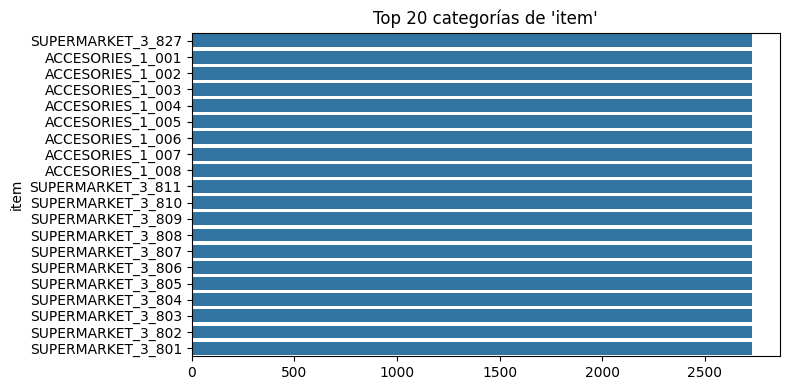


Valores nulos en 'item': 0


In [89]:
univariate_analysis(df_final, "item", cat_threshold=20, top_n=20)

#### Category

La columna 'category' tiene 3 categorías únicas.

Tabla de frecuencia completa:


category
SUPERMARKET      3923010
HOME_&_GARDEN    2858310
ACCESORIES       1542450
Name: count, dtype: int64

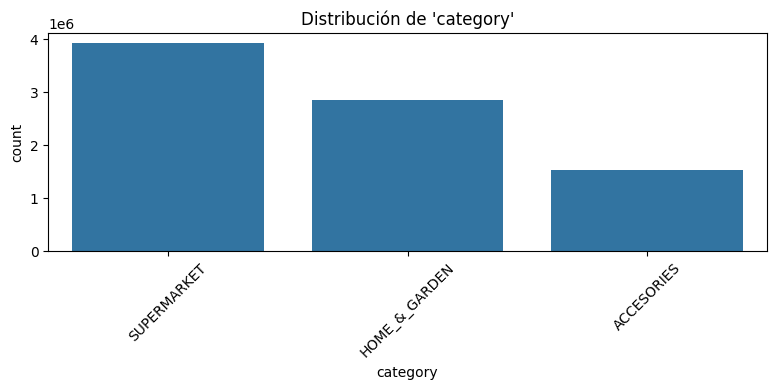


Valores nulos en 'category': 0


In [90]:
univariate_analysis(df_final, "category", cat_threshold=20, top_n=20)

#### Department

La columna 'department' tiene 7 categorías únicas.

Tabla de frecuencia completa:


department
SUPERMARKET_3      2246790
HOME_&_GARDEN_1    1452360
HOME_&_GARDEN_2    1405950
ACCESORIES_1       1135680
SUPERMARKET_2      1086540
SUPERMARKET_1       589680
ACCESORIES_2        406770
Name: count, dtype: int64

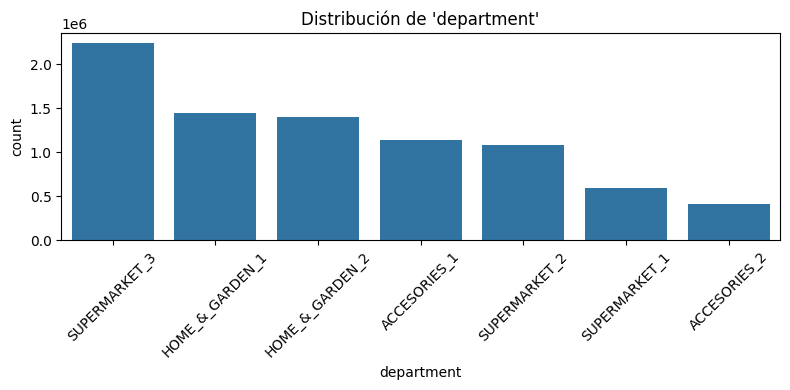


Valores nulos en 'department': 0


In [91]:
univariate_analysis(df_final, "department", cat_threshold=20, top_n=20)

#### Store

La columna 'store' tiene 10 categorías únicas.

Tabla de frecuencia completa:


store
Greenwich_Village    832377
Harlem               832377
Tribeca              832377
Brooklyn             832377
South_End            832377
Roxbury              832377
Back_Bay             832377
Midtown_Village      832377
Yorktown             832377
Queen_Village        832377
Name: count, dtype: int64

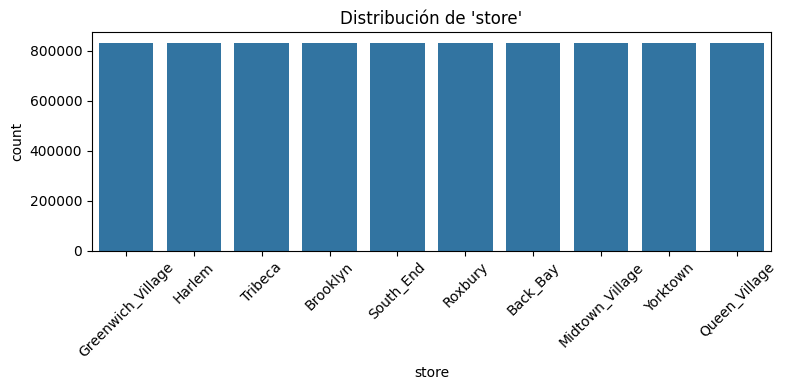


Valores nulos en 'store': 0


In [92]:
univariate_analysis(df_final, "store", cat_threshold=20, top_n=20)

#### Store code

La columna 'store_code' tiene 10 categorías únicas.

Tabla de frecuencia completa:


store_code
NYC_1    832377
NYC_2    832377
NYC_3    832377
NYC_4    832377
BOS_1    832377
BOS_2    832377
BOS_3    832377
PHI_1    832377
PHI_2    832377
PHI_3    832377
Name: count, dtype: int64

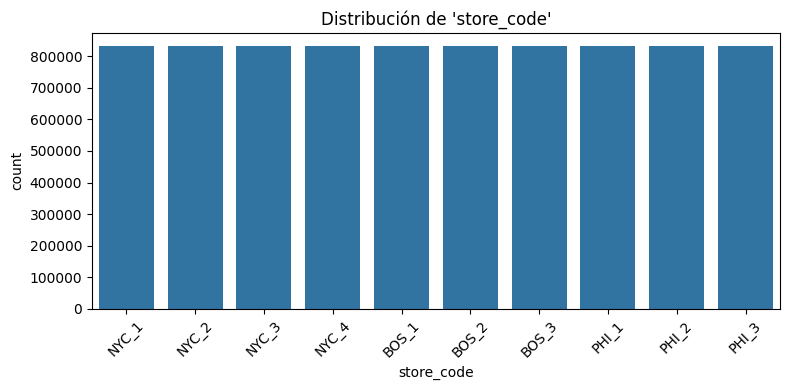


Valores nulos en 'store_code': 0


In [93]:
univariate_analysis(df_final, "store_code", cat_threshold=20, top_n=20)

#### Region

La columna 'region' tiene 3 categorías únicas.

Tabla de frecuencia completa:


region
New York        3329508
Boston          2497131
Philadelphia    2497131
Name: count, dtype: int64

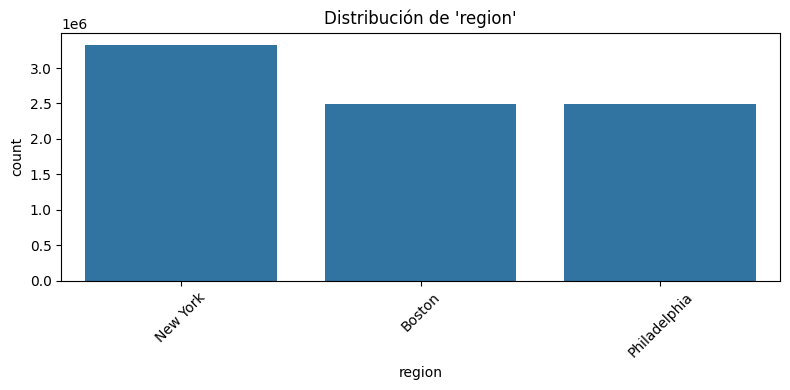


Valores nulos en 'region': 0


In [94]:
univariate_analysis(df_final, "region", cat_threshold=20, top_n=20)

#### Yearweek

La columna 'yearweek' tiene 273 categorías únicas.
La cardinalidad excede el umbral de 20. Mostrando las 20 categorías más frecuentes:



yearweek
201616    30490
201553    30490
201552    30490
201551    30490
201550    30490
201549    30490
201548    30490
201547    30490
201546    30490
201545    30490
201544    30490
201543    30490
201542    30490
201541    30490
201540    30490
201539    30490
201538    30490
201137    30490
201136    30490
201135    30490
Name: count, dtype: int64

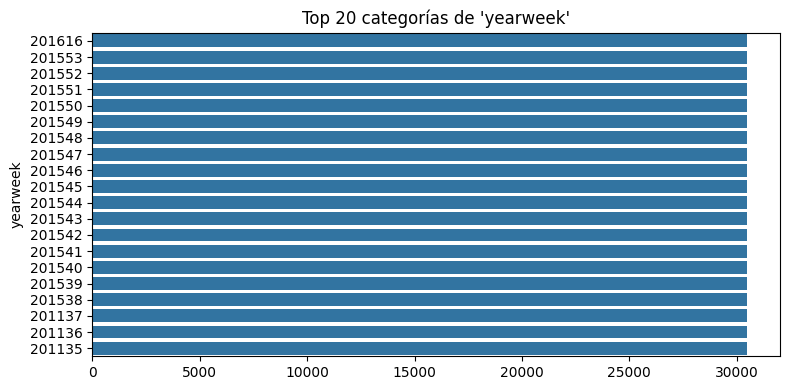


Valores nulos en 'yearweek': 0


In [95]:
univariate_analysis(df_final, "yearweek", cat_threshold=20, top_n=20)

#### Event

La columna 'event' tiene 6 categorías únicas.

Tabla de frecuencia completa:


event
No event          7378580
NewYear            304900
SuperBowl          182940
Ramadan starts     152450
Thanksgiving       152450
Easter             152450
Name: count, dtype: int64

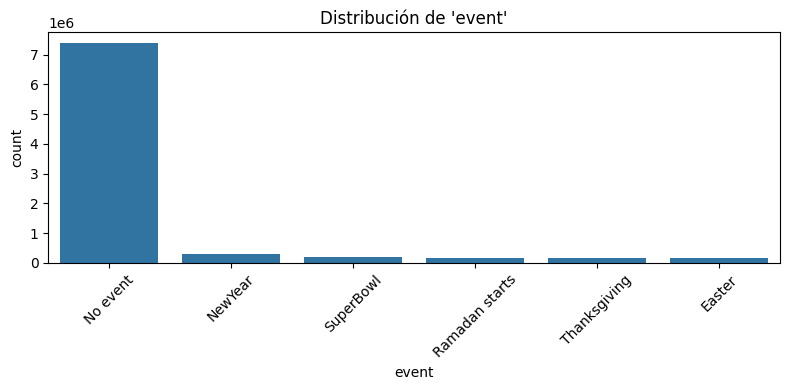


Valores nulos en 'event': 0


In [96]:
univariate_analysis(df_final, "event", cat_threshold=20, top_n=20)

### Numéricas

In [97]:
num_vars = [col for col in df_final.columns if df_final[col].dtype != 'O']
num_vars

['units_sold', 'sell_price', 'year', 'quarter']

In [98]:
target = 'sell_price'

#### Units sold

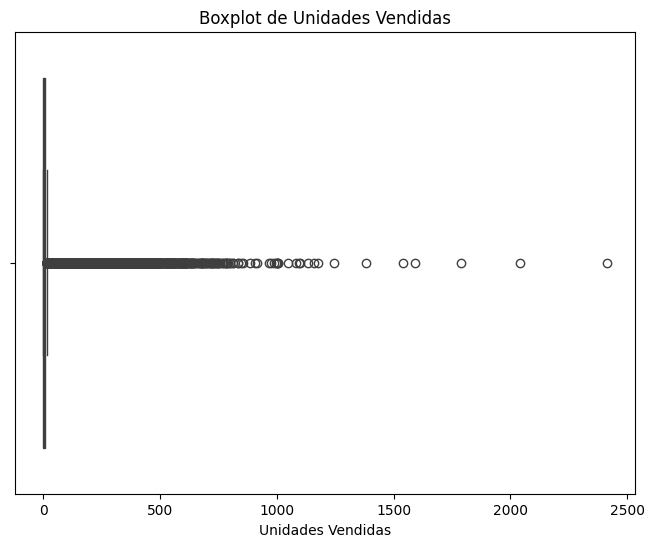

In [99]:
sample_df = df_final.sample(frac=0.1, random_state=42)
plt.figure(figsize=(8, 6))
sns.boxplot(x=sample_df['units_sold'])
plt.title('Boxplot de Unidades Vendidas')
plt.xlabel('Unidades Vendidas')
plt.show()

In [100]:
df_final[df_final["units_sold"]> 2000].head(20)


,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
8640,SUPERMARKET_3_318_NYC_3,SUPERMARKET_3_318,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201105,2211,1.20,2011,1,SuperBowl
1045072,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201139,2220,1.54,2011,3,No event
1349972,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201149,2012,1.54,2011,4,No event
1380462,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201150,2016,1.54,2011,4,No event
1410952,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201151,2412,1.54,2011,4,No event
1441442,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201152,2322,1.54,2011,4,NewYear
1471932,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201201,2237,1.54,2012,1,NewYear
1593892,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201205,2077,1.54,2012,1,SuperBowl
1624382,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201206,2016,1.54,2012,1,No event
2264672,SUPERMARKET_3_090_NYC_3,SUPERMARKET_3_090,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201227,2077,1.54,2012,3,No event


Aunque pueda parecer que tiene algún outlayer, los valores de las ventas con el precio parece estar dentro de lo normal.

#### Year

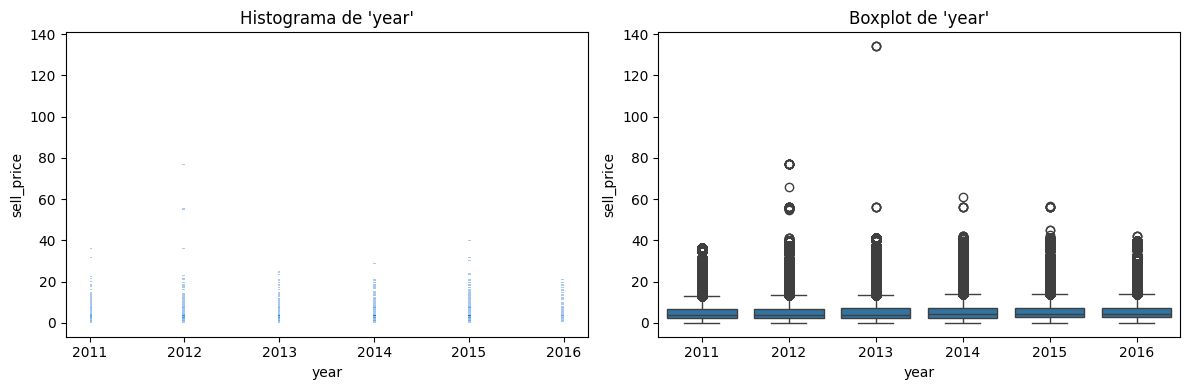

Resumen estadístico de la columna 'year':


count   8323770.00
mean       2013.21
std           1.53
min        2011.00
25%        2012.00
50%        2013.00
75%        2015.00
max        2016.00
Name: year, dtype: float64


Valores nulos en 'year': 0


In [101]:
univariate_analysis(df_final, "year", cat_threshold=20, top_n=20)

#### Quarter

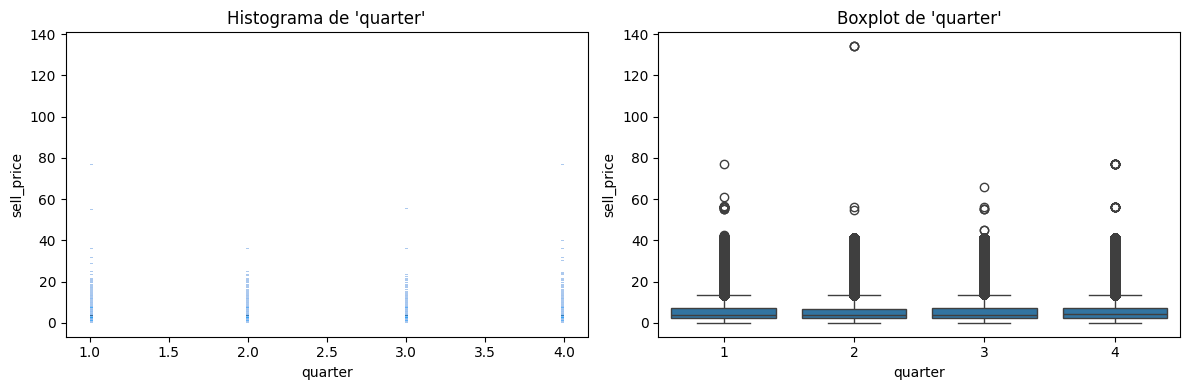

Resumen estadístico de la columna 'quarter':


count   8323770.00
mean          2.41
std           1.12
min           1.00
25%           1.00
50%           2.00
75%           3.00
max           4.00
Name: quarter, dtype: float64


Valores nulos en 'quarter': 0


In [102]:
univariate_analysis(df_final, "quarter", cat_threshold=20, top_n=20)

In [103]:
df_final.head()

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,10.77,2011,1,SuperBowl
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,4.53,2011,1,SuperBowl
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,3.74,2011,1,SuperBowl
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,5.96,2011,1,SuperBowl
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,3.17,2011,1,SuperBowl


In [104]:
df_final["units_sold"].sum()

np.int64(65509301)

# Comenzamos con el primer email recibido.

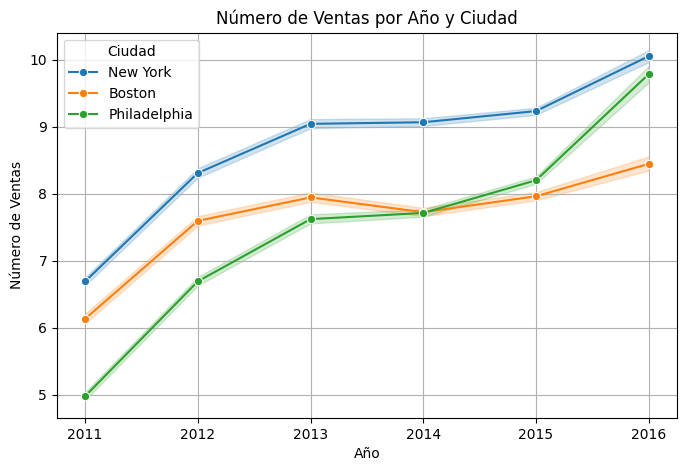

In [105]:
# Creamos un grafico para ver el numero de ventas por año y por ciudad.

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_final, x="year", y="units_sold", hue="region", marker="o")

plt.title("Número de Ventas por Año y Ciudad")
plt.xlabel("Año")
plt.ylabel("Número de Ventas")
plt.grid(True)
plt.legend(title="Ciudad")
plt.show()


- En general, podemos observar que la empresa ha ido aumentando el numero de ventas independientemente de la ciudad. 
- Sí que se observa que el aumento más significativo ha sido en Philadelphia, aumentando desde 5 millones de ventas por año a alrededor de 9 millones y medio de ventas.
- El incremento en New York y Boston parece bastante similar aunque un poco mayor en Nueva York.
- En los datos más recientes podemos ver que, las cuidades con más ventas en orden descendente son New York, Philadelphia y Boston. Siendo las dos primeras muy similares.
- Siguiendo la tendecia de los últimos años, parece que las cosas en Philadelphia se están haciendo muy bien y van al alza por lo que, posiblemente, en el siguiente año será la ciudad con más ventas. 

Realizamos el gráfico de Pareto para comprobar que no haya productos sin ventas y observar cuántos artículos acumulan el 80% de las ventas de cada tienda

         Ciudad  Productos con Ventas  Productos que generan el 80% de ventas  \
0        Boston                  3049                                     912   
1      New York                  3049                                    1050   
2  Philadelphia                  3049                                     962   

   Total de Productos  % Productos con Ventas  
0                3049                  100.00  
1                3049                  100.00  
2                3049                  100.00  


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\3922604539.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  productos_pareto = ventas_por_producto.groupby("region").apply(calcular_pareto).reset_index()


<Figure size 1000x600 with 0 Axes>

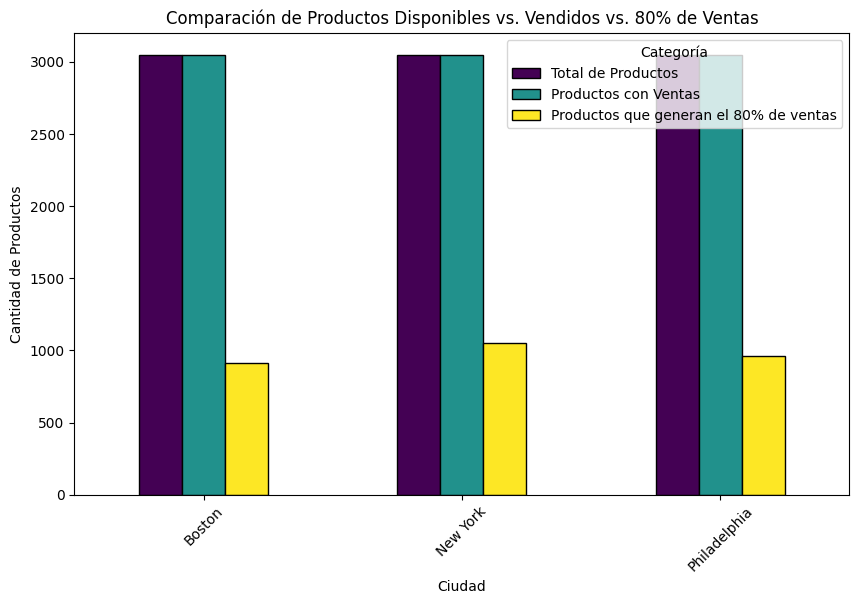

In [106]:
total_productos = df_final["item"].nunique()

productos_vendidos = df_final[df_final["units_sold"] > 0].groupby("region")["item"].nunique().reset_index()
productos_vendidos.columns = ["Ciudad", "Productos con Ventas"]

# Calculamos la cantidad de productos que generan el 80% de las ventas
ventas_por_producto = df_final.groupby(["region", "item"])["units_sold"].sum().reset_index()
ventas_por_producto = ventas_por_producto.sort_values(by=["region", "units_sold"], ascending=[True, False])

productos_pareto = ventas_por_producto.groupby("region").apply(calcular_pareto).reset_index()
productos_pareto.columns = ["Ciudad", "Productos que generan el 80% de ventas"]

comparacion_productos = productos_vendidos.merge(productos_pareto, on="Ciudad")
comparacion_productos["Total de Productos"] = total_productos

# Calculamos porcentaje de productos vendidos sobre el total
comparacion_productos["% Productos con Ventas"] = (comparacion_productos["Productos con Ventas"] / total_productos) * 100

# Mostramos tabla de comparación
print(comparacion_productos)

# Mostramos el gráfico
plt.figure(figsize=(10,6))

comparacion_productos.set_index("Ciudad")[["Total de Productos", "Productos con Ventas", "Productos que generan el 80% de ventas"]].plot(
    kind="bar", figsize=(10,6), colormap="viridis", edgecolor="black"
)

plt.xlabel("Ciudad")
plt.ylabel("Cantidad de Productos")
plt.title("Comparación de Productos Disponibles vs. Vendidos vs. 80% de Ventas")
plt.xticks(rotation=45)
plt.legend(title="Categoría")
plt.show()


- Observamos que la totalidad de los artículos tienen movimientos. No hay ningún artículo que no tenga ninguna venta.
- En las tres ciudades, aproximadamente el 30% de los artículos concentran el 80% de las ventas.

### Vamos a separar el Dataset en 3. Uno para cada una de las regiones ya que habra que analizar los productos dependiendo de la region.

In [107]:
df_ny = df_final[df_final["region"]== "New York"]
df_boston = df_final[df_final["region"]== "Boston"]
df_phi = df_final[df_final["region"]== "Philadelphia"]

## Analizamos el dataframe para New York.

In [108]:
df_ny.shape

(3329508, 13)

In [109]:
df_ny.head()

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,10.77,2011,1,SuperBowl
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,4.53,2011,1,SuperBowl
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,3.74,2011,1,SuperBowl
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,5.96,2011,1,SuperBowl
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,3.17,2011,1,SuperBowl


#### Vamos a agrupar por año e item primero y luego le añadimos tienda también.

In [110]:
agrupado_ny = (
    df_ny.groupby(["year", "item"])["units_sold"].sum().reset_index()
    .sort_values(["year", "item", "units_sold"], ascending=[True, True, False]) 
)

agrupado_ny.head(20)

,year,item,units_sold
0,2011,ACCESORIES_1_001,0
1,2011,ACCESORIES_1_002,188
2,2011,ACCESORIES_1_003,0
3,2011,ACCESORIES_1_004,3116
4,2011,ACCESORIES_1_005,1214
5,2011,ACCESORIES_1_006,0
6,2011,ACCESORIES_1_007,0
7,2011,ACCESORIES_1_008,10726
8,2011,ACCESORIES_1_009,1446
9,2011,ACCESORIES_1_010,748


In [111]:
agrupado_ny.shape

(18294, 3)

In [112]:
agrupado_ny1 = (
    df_ny.groupby(["year", "item", "store"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(["year", "item", "units_sold"], ascending=[True, True, False])
)


In [113]:
agrupado_ny1.shape

(73176, 4)

In [114]:
agrupado_ny1.head(20)

,year,item,store,units_sold
0,2011,ACCESORIES_1_001,Brooklyn,0
1,2011,ACCESORIES_1_001,Greenwich_Village,0
2,2011,ACCESORIES_1_001,Harlem,0
3,2011,ACCESORIES_1_001,Tribeca,0
6,2011,ACCESORIES_1_002,Harlem,66
5,2011,ACCESORIES_1_002,Greenwich_Village,58
7,2011,ACCESORIES_1_002,Tribeca,39
4,2011,ACCESORIES_1_002,Brooklyn,25
8,2011,ACCESORIES_1_003,Brooklyn,0
9,2011,ACCESORIES_1_003,Greenwich_Village,0


In [115]:
agrupado_ny1.item.nunique()

3049

In [116]:
# Agrupamos por año y producto y calculamos la diferencia de ventas que ha habido con el año anterior.

ventas_por_producto = df_ny.groupby(["year", "item"])["units_sold"].sum().reset_index()

ventas_por_producto = ventas_por_producto.sort_values(["item", "year"])

ventas_por_producto["diferencia"] = ventas_por_producto.groupby("item")["units_sold"].diff()

print(ventas_por_producto)



       year               item  units_sold  diferencia
0      2011   ACCESORIES_1_001           0         NaN
3049   2012   ACCESORIES_1_001           0        0.00
6098   2013   ACCESORIES_1_001         399      399.00
9147   2014   ACCESORIES_1_001         820      421.00
12196  2015   ACCESORIES_1_001         922      102.00
...     ...                ...         ...         ...
6097   2012  SUPERMARKET_3_827           0        0.00
9146   2013  SUPERMARKET_3_827           0        0.00
12195  2014  SUPERMARKET_3_827         715      715.00
15244  2015  SUPERMARKET_3_827        2452     1737.00
18293  2016  SUPERMARKET_3_827        1982     -470.00

[18294 rows x 4 columns]


Aplicamos la función de pareto para las diferentes tiendas de Nueva York

C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


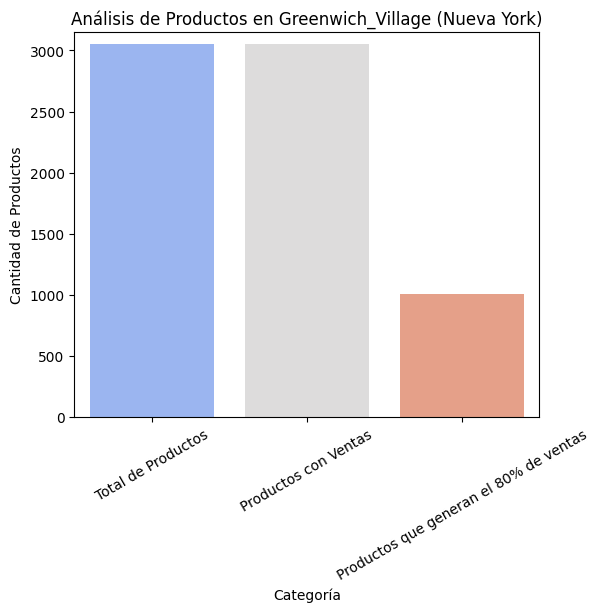

**Análisis de la tienda Greenwich_Village en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 1009
--------------------------------------------------


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


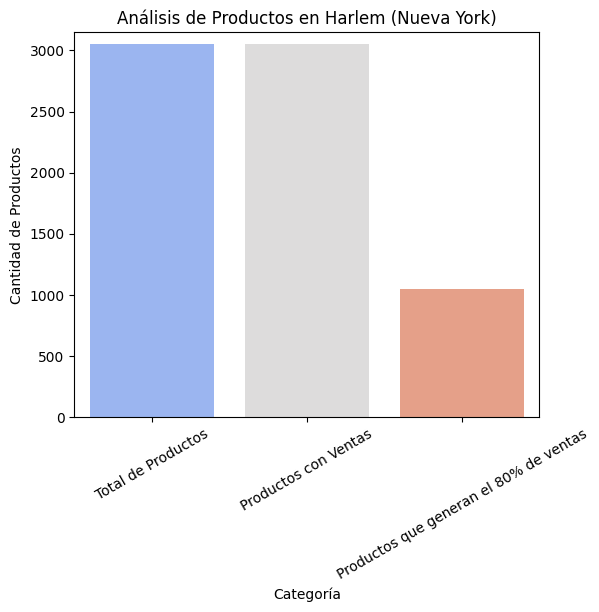

**Análisis de la tienda Harlem en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 1047
--------------------------------------------------


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


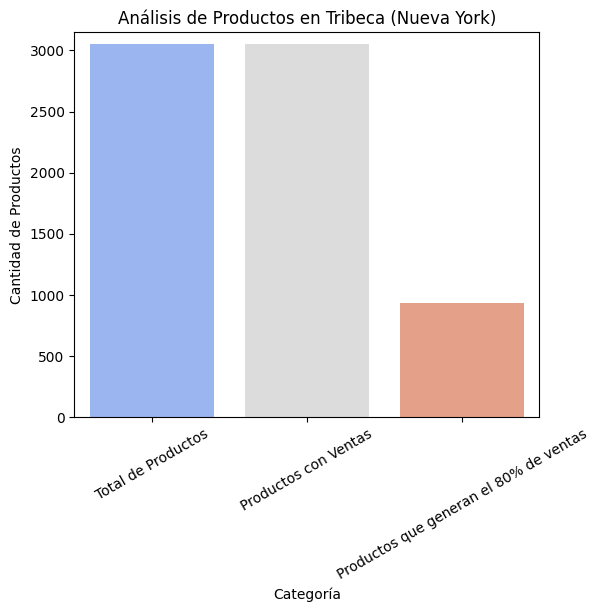

**Análisis de la tienda Tribeca en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 930
--------------------------------------------------


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


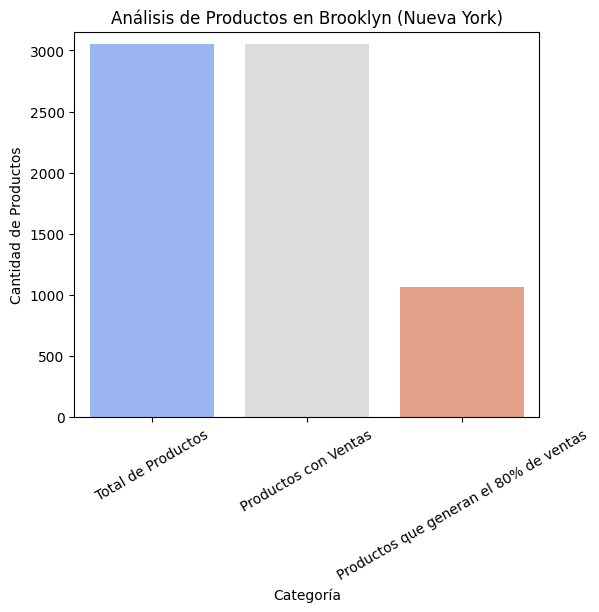

**Análisis de la tienda Brooklyn en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 1061
--------------------------------------------------


In [117]:
pareto_por_tiendas(df_ny)

Items que más han decrecido del primer al último año en New York.

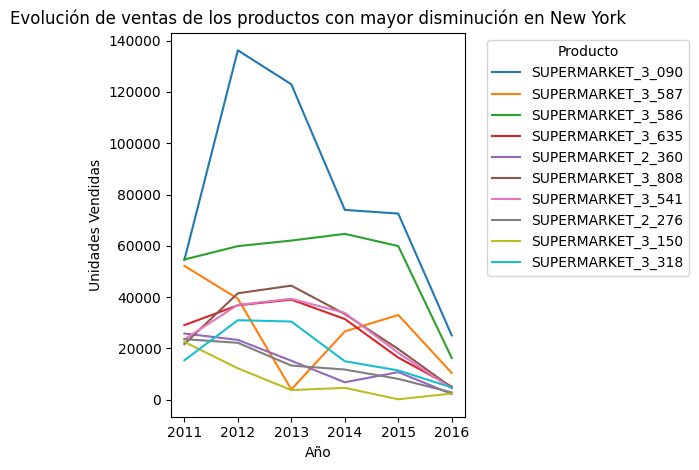

In [118]:
# Agrupamos por 'item' y 'year', sumando las unidades vendidas
ventas_por_item_ny = df_ny.groupby(['item', 'year'])['units_sold'].sum().unstack()

# Calculamos la pendiente para cada ítem
pendientes_ny = ventas_por_item_ny.apply(calcular_pendiente, axis=1)

# Filtramos los productos con pendiente negativa (disminución en ventas)
productos_decrecientes_ny = pendientes_ny[pendientes_ny < 0]

# Mostramos los 10 productos con mayor disminución en ventas (mayor pendiente negativa)
productos_decrecientes_ny = productos_decrecientes_ny.sort_values()

# Creamos una nueva columna en df_final para indicar si el producto es decreciente
df_final['producto_decreciente_ny'] = df_final['item'].isin(productos_decrecientes_ny.index)

# Graficamos la evolución de ventas de los productos con mayor disminución
for item in productos_decrecientes_ny.head(10).index:
    item_sales = ventas_por_item_ny.loc[item]
    plt.plot(item_sales.index, item_sales.values, label=item)

plt.title('Evolución de ventas de los productos con mayor disminución en New York')
plt.xlabel('Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Items que más han crecido del primer al último año

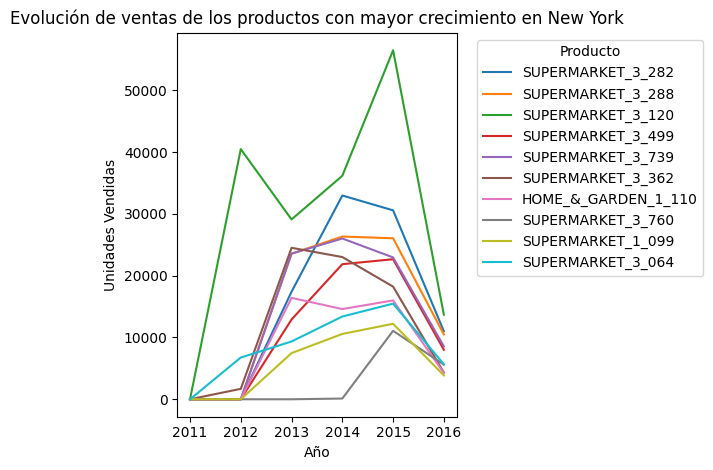

In [119]:
productos_crecientes_ny = pendientes_ny[pendientes_ny > 0]

# Mostrarmos los 10 productos con mayor crecimiento en ventas (mayor pendiente positiva)
productos_crecientes_ny = productos_crecientes_ny.sort_values(ascending=False)

# Creamos una nueva columna en df_final para indicar si el producto es creciente
df_final['producto_creciente_ny'] = df_final['item'].isin(productos_crecientes_ny.index)

# Graficamos la evolución de ventas de los productos con mayor crecimiento
for item in productos_crecientes_ny.head(10).index:
    item_sales = ventas_por_item_ny.loc[item]
    plt.plot(item_sales.index, item_sales.values, label=item)

plt.title('Evolución de ventas de los productos con mayor crecimiento en New York')
plt.xlabel('Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [120]:
df_final.head()

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event,producto_decreciente_ny,producto_creciente_ny
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,10.77,2011,1,SuperBowl,False,True
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,4.53,2011,1,SuperBowl,True,False
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,3.74,2011,1,SuperBowl,False,True
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,5.96,2011,1,SuperBowl,True,False
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,201105,0,3.17,2011,1,SuperBowl,True,False


## Analizamos el dataframe para Boston

In [121]:
df_boston.shape


(2497131, 13)

In [122]:
df_boston.head()


,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
12196,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,201105,0,10.77,2011,1,SuperBowl
12197,ACCESORIES_1_002_BOS_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,201105,0,5.15,2011,1,SuperBowl
12198,ACCESORIES_1_003_BOS_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,201105,0,3.74,2011,1,SuperBowl
12199,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,201105,13,5.77,2011,1,SuperBowl
12200,ACCESORIES_1_005_BOS_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,201105,0,3.07,2011,1,SuperBowl


In [123]:
agrupado_boston = (
    df_ny.groupby(["year", "item"])["units_sold"].sum().reset_index()
    .sort_values(["year", "item", "units_sold"], ascending=[True, True, False]) 
)

agrupado_boston.head(20)

,year,item,units_sold
0,2011,ACCESORIES_1_001,0
1,2011,ACCESORIES_1_002,188
2,2011,ACCESORIES_1_003,0
3,2011,ACCESORIES_1_004,3116
4,2011,ACCESORIES_1_005,1214
5,2011,ACCESORIES_1_006,0
6,2011,ACCESORIES_1_007,0
7,2011,ACCESORIES_1_008,10726
8,2011,ACCESORIES_1_009,1446
9,2011,ACCESORIES_1_010,748


In [124]:
agrupado_boston.shape


(18294, 3)

In [125]:
agrupado_boston1 = (
    df_boston.groupby(["year", "item", "store"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(["year", "item", "units_sold"], ascending=[True, True, False])
)

In [126]:
agrupado_boston1.shape

(54882, 4)

In [127]:
agrupado_boston1.item.nunique()


3049

C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


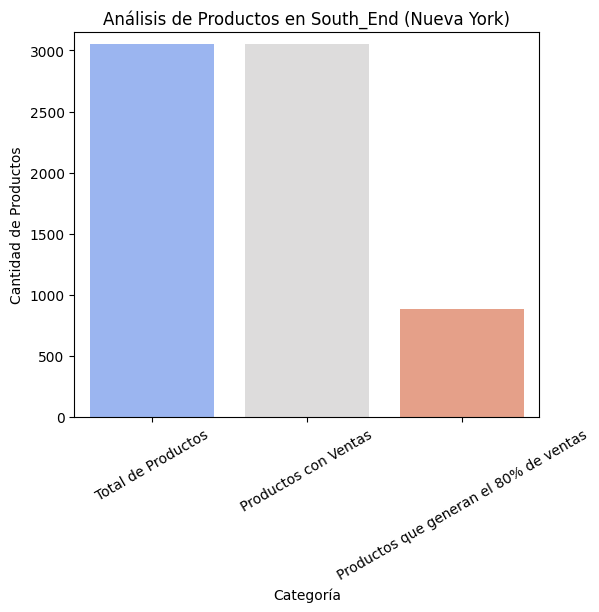

**Análisis de la tienda South_End en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 882
--------------------------------------------------


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


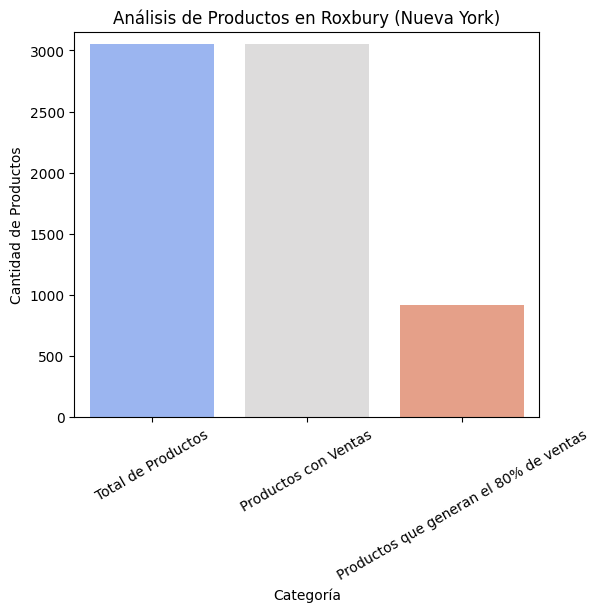

**Análisis de la tienda Roxbury en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 915
--------------------------------------------------


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


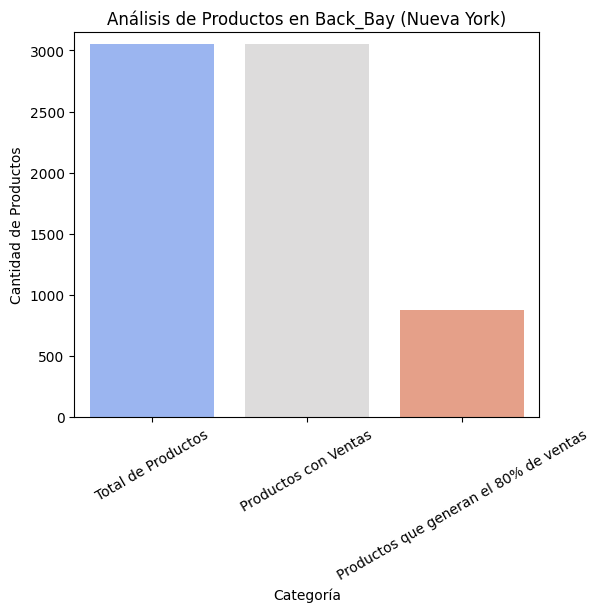

**Análisis de la tienda Back_Bay en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 878
--------------------------------------------------


In [128]:
pareto_por_tiendas(df_boston)

Items que más han decrecido del primer al último año en Boston.


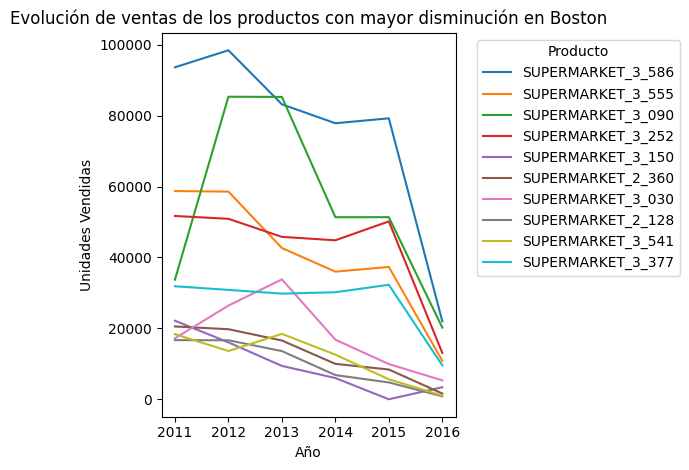

In [129]:
# Agrupamos por 'item' y 'year', sumando las unidades vendidas
ventas_por_item_boston = df_boston.groupby(['item', 'year'])['units_sold'].sum().unstack()

# Calculamos la pendiente para cada ítem
pendientes_boston = ventas_por_item_boston.apply(calcular_pendiente, axis=1)

# Filtramos los productos con pendiente negativa (disminución en ventas)
productos_decrecientes_boston = pendientes_boston[pendientes_boston < 0]

# Mostramos los 10 productos con mayor disminución en ventas (mayor pendiente negativa)
productos_decrecientes_boston = productos_decrecientes_boston.sort_values()

# Creamos una nueva columna en df_final para indicar si el producto es decreciente
df_final['producto_decreciente_boston'] = df_final['item'].isin(productos_decrecientes_boston.index)

# Graficamos la evolución de ventas de los productos con mayor disminución
for item in productos_decrecientes_boston.head(10).index:
    item_sales = ventas_por_item_boston.loc[item]
    plt.plot(item_sales.index, item_sales.values, label=item)

plt.title('Evolución de ventas de los productos con mayor disminución en Boston')
plt.xlabel('Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Items que más han crecido del primer al último año


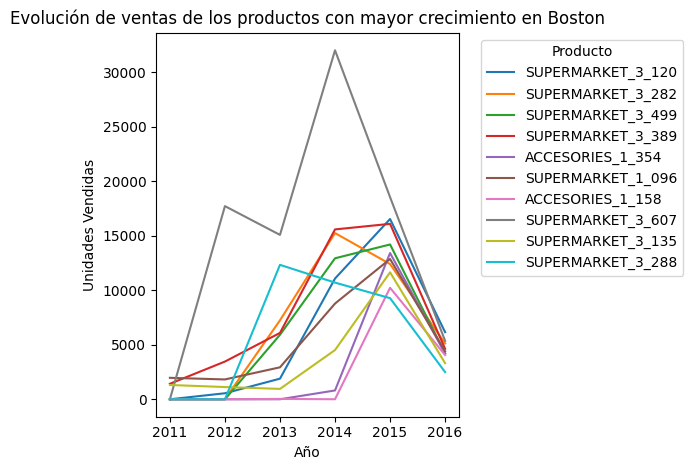

In [130]:
productos_crecientes_boston = pendientes_boston[pendientes_boston > 0]

# Mostrarmos los 10 productos con mayor crecimiento en ventas (mayor pendiente positiva)
productos_crecientes_boston = productos_crecientes_boston.sort_values(ascending=False)

# Creamos una nueva columna en df_final para indicar si el producto es creciente
df_final['producto_creciente_boston'] = df_final['item'].isin(productos_crecientes_boston.index)


# Graficamos la evolución de ventas de los productos con mayor crecimiento
for item in productos_crecientes_boston.head(10).index:
    item_sales = ventas_por_item_boston.loc[item]
    plt.plot(item_sales.index, item_sales.values, label=item)

plt.title('Evolución de ventas de los productos con mayor crecimiento en Boston')
plt.xlabel('Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [131]:
df_final.sample(10)

,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event,producto_decreciente_ny,producto_creciente_ny,producto_decreciente_boston,producto_creciente_boston
226076,ACCESORIES_2_035_BOS_1,ACCESORIES_2_035,ACCESORIES,ACCESORIES_2,South_End,BOS_1,Boston,201112,0,5.13,2011,1,No event,False,True,False,True
2977181,HOME_&_GARDEN_2_262_BOS_3,HOME_&_GARDEN_2_262,HOME_&_GARDEN,HOME_&_GARDEN_2,Back_Bay,BOS_3,Boston,201250,1,6.21,2012,4,No event,True,False,True,False
5390613,SUPERMARKET_3_809_PHI_1,SUPERMARKET_3_809,SUPERMARKET,SUPERMARKET_3,Midtown_Village,PHI_1,Philadelphia,201425,29,1.20,2014,2,No event,False,True,False,True
6613649,ACCESORIES_1_377_PHI_3,ACCESORIES_1_377,ACCESORIES,ACCESORIES_1,Queen_Village,PHI_3,Philadelphia,201513,2,13.27,2015,1,No event,True,False,True,False
1311063,SUPERMARKET_3_821_PHI_3,SUPERMARKET_3_821,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,201147,0,5.66,2011,4,Thanksgiving,False,True,False,True
1087689,SUPERMARKET_3_020_BOS_3,SUPERMARKET_3_020,SUPERMARKET,SUPERMARKET_3,Back_Bay,BOS_3,Boston,201140,0,1.42,2011,4,No event,True,False,True,False
950475,SUPERMARKET_3_011_NYC_2,SUPERMARKET_3_011,SUPERMARKET,SUPERMARKET_3,Harlem,NYC_2,New York,201136,20,2.38,2011,3,No event,True,False,True,False
3698302,SUPERMARKET_3_690_NYC_3,SUPERMARKET_3_690,SUPERMARKET,SUPERMARKET_3,Tribeca,NYC_3,New York,201322,0,10.37,2013,2,No event,False,True,False,True
4195842,ACCESORIES_2_003_BOS_3,ACCESORIES_2_003,ACCESORIES,ACCESORIES_2,Back_Bay,BOS_3,Boston,201338,2,2.62,2013,3,No event,True,False,False,True
4564192,SUPERMARKET_3_664_BOS_3,SUPERMARKET_3_664,SUPERMARKET,SUPERMARKET_3,Back_Bay,BOS_3,Boston,201350,0,2.74,2013,4,No event,True,False,True,False


In [132]:
df_final["producto_decreciente_boston"].describe()

count     8323770
unique          2
top          True
freq      4591860
Name: producto_decreciente_boston, dtype: object

## Analizamos el dataframe para Philadelphia

In [133]:
df_phi.shape


(2497131, 13)

In [134]:
df_phi.head()


,id,item,category,department,store,store_code,region,yearweek,units_sold,sell_price,year,quarter,event
21343,ACCESORIES_1_001_PHI_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Midtown_Village,PHI_1,Philadelphia,201105,0,10.77,2011,1,SuperBowl
21344,ACCESORIES_1_002_PHI_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Midtown_Village,PHI_1,Philadelphia,201105,0,5.15,2011,1,SuperBowl
21345,ACCESORIES_1_003_PHI_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Midtown_Village,PHI_1,Philadelphia,201105,0,3.74,2011,1,SuperBowl
21346,ACCESORIES_1_004_PHI_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Midtown_Village,PHI_1,Philadelphia,201105,4,5.77,2011,1,SuperBowl
21347,ACCESORIES_1_005_PHI_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Midtown_Village,PHI_1,Philadelphia,201105,0,2.96,2011,1,SuperBowl


In [135]:
agrupado_phi = (
    df_ny.groupby(["year", "item"])["units_sold"].sum().reset_index()
    .sort_values(["year", "item", "units_sold"], ascending=[True, True, False]) 
)

agrupado_phi.head(20)

,year,item,units_sold
0,2011,ACCESORIES_1_001,0
1,2011,ACCESORIES_1_002,188
2,2011,ACCESORIES_1_003,0
3,2011,ACCESORIES_1_004,3116
4,2011,ACCESORIES_1_005,1214
5,2011,ACCESORIES_1_006,0
6,2011,ACCESORIES_1_007,0
7,2011,ACCESORIES_1_008,10726
8,2011,ACCESORIES_1_009,1446
9,2011,ACCESORIES_1_010,748


In [136]:
agrupado_phi.shape


(18294, 3)

In [137]:
agrupado_phi1 = (
    df_ny.groupby(["year", "item", "store"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(["year", "item", "units_sold"], ascending=[True, True, False])
)

In [138]:
agrupado_phi1.shape


(73176, 4)

In [139]:
agrupado_phi1.item.nunique()


3049

In [140]:
# Agrupamos por año y producto y calculamos la diferencia de ventas que ha habido con el año anterior.

ventas_por_producto = df_phi.groupby(["year", "item"])["units_sold"].sum().reset_index()

ventas_por_producto = ventas_por_producto.sort_values(["item", "year"])

ventas_por_producto["diferencia"] = ventas_por_producto.groupby("item")["units_sold"].diff()

print(ventas_por_producto)

       year               item  units_sold  diferencia
0      2011   ACCESORIES_1_001           0         NaN
3049   2012   ACCESORIES_1_001           0        0.00
6098   2013   ACCESORIES_1_001          46       46.00
9147   2014   ACCESORIES_1_001         148      102.00
12196  2015   ACCESORIES_1_001         229       81.00
...     ...                ...         ...         ...
6097   2012  SUPERMARKET_3_827           0        0.00
9146   2013  SUPERMARKET_3_827           0        0.00
12195  2014  SUPERMARKET_3_827        1603     1603.00
15244  2015  SUPERMARKET_3_827        2386      783.00
18293  2016  SUPERMARKET_3_827         913    -1473.00

[18294 rows x 4 columns]


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


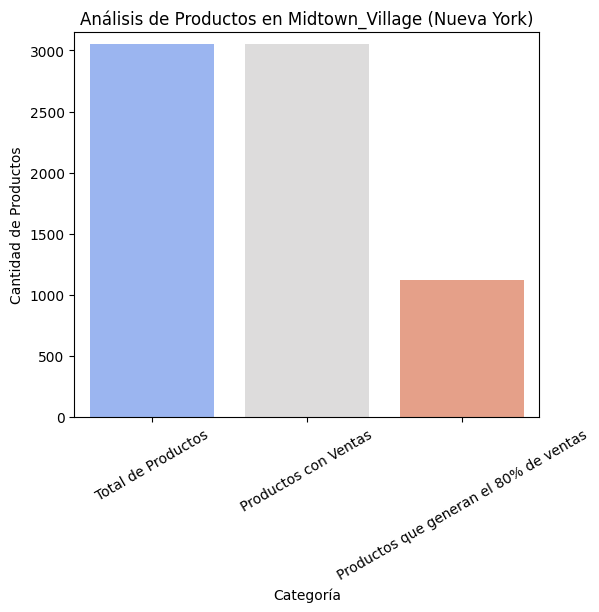

**Análisis de la tienda Midtown_Village en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 1118
--------------------------------------------------


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


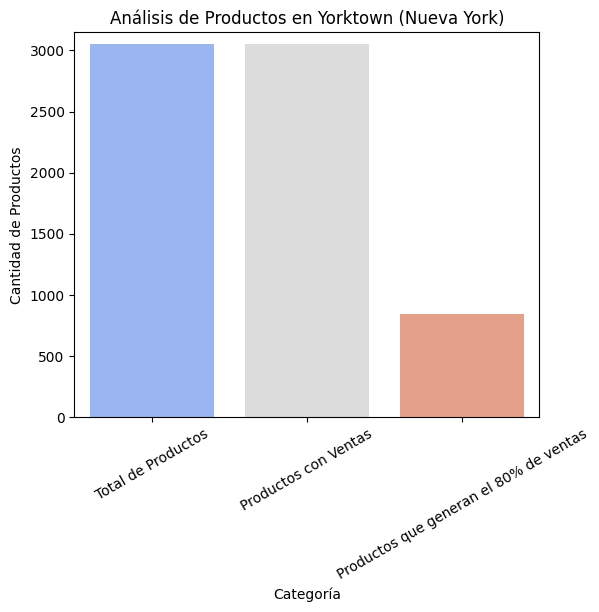

**Análisis de la tienda Yorktown en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 843
--------------------------------------------------


C:\Users\jorda\AppData\Local\Temp\ipykernel_12892\1280512415.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion_tienda, x="Categoría", y="Cantidad", palette="coolwarm")


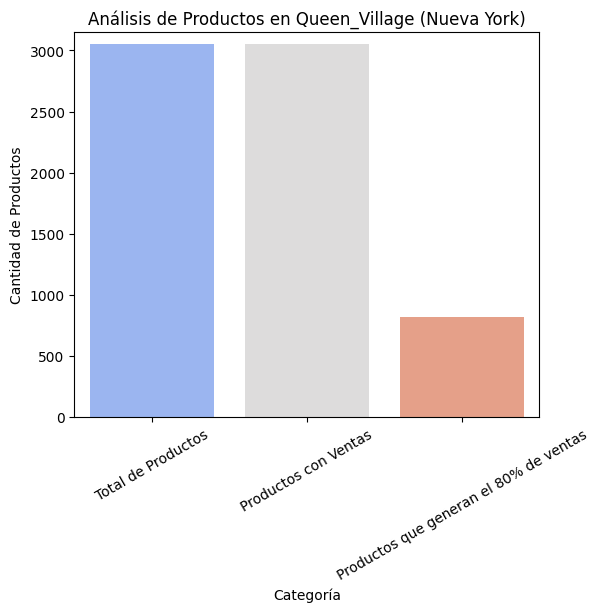

**Análisis de la tienda Queen_Village en Nueva York:**
- Total de productos disponibles: 3049
- Productos con al menos una venta: 3049 (100.00%)
- Productos que generan el 80% de las ventas: 820
--------------------------------------------------


In [141]:
pareto_por_tiendas(df_phi)

Items que más han decrecido del primer al último año en Philadelphia.


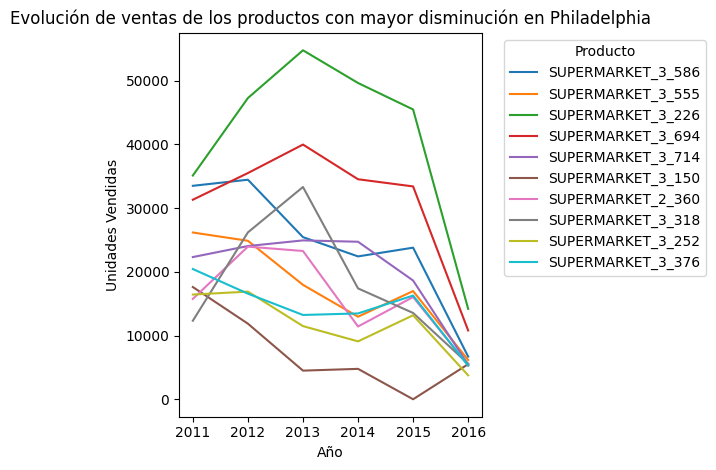

In [142]:
# Agrupamos por 'item' y 'year', sumando las unidades vendidas
ventas_por_item_phi = df_phi.groupby(['item', 'year'])['units_sold'].sum().unstack()

# Calculamos la pendiente para cada ítem
pendientes_phi = ventas_por_item_phi.apply(calcular_pendiente, axis=1)

# Filtramos los productos con pendiente negativa (disminución en ventas)
productos_decrecientes_phi = pendientes_phi[pendientes_phi < 0]

# Mostramos los 10 productos con mayor disminución en ventas (mayor pendiente negativa)
productos_decrecientes_phi = productos_decrecientes_phi.sort_values()

# Creamos una nueva columna en df_final para indicar si el producto es decreciente
df_final['producto_decreciente_phi'] = df_final['item'].isin(productos_decrecientes_phi.index)

# Graficamos la evolución de ventas de los productos con mayor disminución
for item in productos_decrecientes_phi.head(10).index:
    item_sales = ventas_por_item_phi.loc[item]
    plt.plot(item_sales.index, item_sales.values, label=item)

plt.title('Evolución de ventas de los productos con mayor disminución en Philadelphia')
plt.xlabel('Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Items que más han crecido del primer al último año


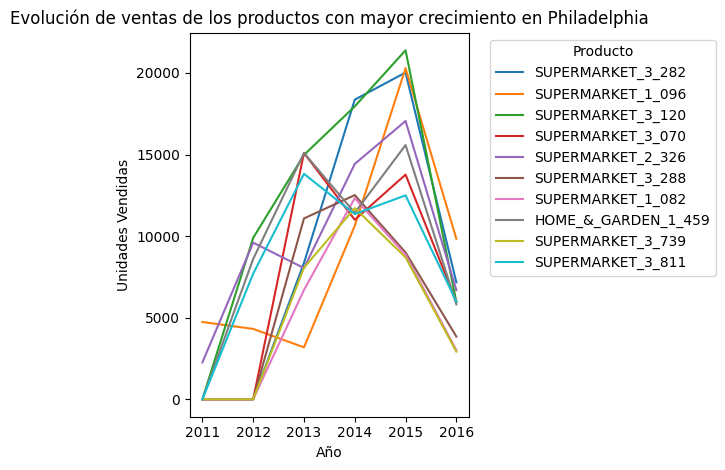

In [143]:
productos_crecientes_phi = pendientes_phi[pendientes_phi > 0]

# Mostrarmos los 10 productos con mayor crecimienot en ventas (mayor pendiente positiva)
productos_crecientes_phi = productos_crecientes_phi.sort_values(ascending=False)

# Creamos una nueva columna en df_final para indicar si el producto es creciente
df_final['producto_creciente_phi'] = df_final['item'].isin(productos_crecientes_phi.index)


# Graficamos la evolución de ventas de los productos con mayor crecimiento
for item in productos_crecientes_phi.head(10).index:
    item_sales = ventas_por_item_phi.loc[item]
    plt.plot(item_sales.index, item_sales.values, label=item)

plt.title('Evolución de ventas de los productos con mayor crecimiento en Philadelphia')
plt.xlabel('Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [144]:
df_final.to_pickle('data/pickles/df_analisis.pkl')
